In [14]:
import numpy as np
from scipy import stats
from scipy.stats import binom
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from pathlib import Path
from collections import Counter

In [9]:
# 01. load mtcars dataset
project_root = Path.cwd().parents[0]
fname = project_root / "datasets" / "mtcars.csv"

# verify the path
#print(fname)

df = pd.read_csv(fname)

## Binomial Distribution

consider a deck of 52 playing cards  
A trial: drawing a card at random out of the deck  
Success: drawing an Ace  
P(success) = 4/52 = 0.076923  
an experiment has 20 trials

What is the probability of selecting an ace 5 times out of 20 trials?


In [15]:
# PMF: Probability Mass Function
# PMF: probability of EXACTLY 5 aces in 20 trials
#   k = number of successes we're asking about
#   n = number of trials in one experiment
#   p = probability of success on a single trial
prob = binom.pmf(k=5, n=20, p=0.0769)
print(f"probabiliy of pulling an ace 5 times out of 20 trials: {prob:0.2%}")

# CDF: Comulative Distribution Function 
# CDF: probability of 5 OR FEWER aces in 20 trials
prob = binom.cdf(k=5, n=20, p=0.0769)
print(f"probabiliy of pulling an ace '5 times or less' out of 20 trials: {prob:0.2%}")


probabiliy of pulling an ace 5 times out of 20 trials: 1.26%
probabiliy of pulling an ace '5 times or less' out of 20 trials: 99.69%


#### example 4.14 in the openstax book  

consider a catalog with 560 pages, 8 pf them feature signature artists
A trial: looking at one page out of the sampled 100  
Success: drawing a signature artist page  
P(success) = 8/560 = 1/70 = 0.0143  
X (the random variable): the count of successes in one experiment (i.e. across the 100 trials of an experiment)  
An experiment has 100 pages, i.e. n = 100 trials  

What is the probability of selecting an ace 5 times out of 20 trials?

| Variable |  value  | meaning |
|----------|---------|---------|
| N        | 560     | Total pages in the catalog  |
| N_success| 8       | pages featuring signature artists |
| n        | 100     | Number of pages sampled (i.e. number of trials in one experiment) |
| p        | 0.0143  | probability of a success |
| q        | 0.9857  | probability of a failure (1 - p) |


a. what values does x take on? x = {0, 1, 2, 3, 4, 5, 6, 7, 8}  
b. what is the probability distribution?  
$X \sim B(n, p)$  
$X \sim B(100, \frac{8}{560})$

$$P(X = x) = \binom{n}{x} p^x (1-p)^{n-x}, \quad x = 0, 1, 2, \dots, n$$

$$\mu = np$$

$$\sigma^2 = np(1-p)$$

$$\sigma = \sqrt{np(1-p)}$$

-------
$$P(X = x) = \binom{100}{x} \left(\frac{8}{560}\right)^x \left(\frac{552}{560}\right)^{100-x}, \quad x = 0, 1, 2, \dots, 8$$

$$\mu = 100 \cdot \frac{8}{560} \approx 1.4286$$

$$\sigma^2 = 100 \cdot \frac{8}{560} \cdot \frac{552}{560} \approx 1.4082$$

$$\sigma = \sqrt{1.4082} \approx 1.1867$$

-----------

Notice the CDF calculates the OR probability, which is the sum up to the upper bound value  
i.e P(x=0) + p(x=1) + .... + (p(x=k))

In [ ]:
## b. find the following probabilites
# 1. probability of 2 pages feature signature artists
prob_2 = binom.pmf(k=2, n=100, p=(8/560))
print(f"probabiliy of 2 pages featuring signature artists P(x=2): {prob_2:0.2%}")

# 2. probability that at most 6 pages feature signature artists
prob_atmost_6 = binom.cdf(k=6, n=100, p=(8/560))
print(f"probabiliy of at most 6 pages featuring signature artists P(x<=6): {prob_atmost_6:0.2%}")

# 3. the probability that more than 3 pages feature signature artists
# prob_atleast_3 = 1 - binom.cdf(k=3, n=100, p=(8/560))
prob_atleast_3 = binom.sf(k=3, n=100, p=(8/560))
print(f"probabiliy that 3 or more pages featuring signature artists P(x>3): {prob_atleast_3:0.2%}")

## c. calculate
# 1. mean
mean = binom.mean(n=100, p=(8/560))
sd = binom.std(n=100, p=(8/560))
print(f"mean: {mean:0.4f}\nstd:{sd:0.4f}")
# 2. standard deviation

probabiliy of 2 pages featuring signature artists P(x=2): 24.66%
probabiliy of at most 6 pages featuring signature artists P(x<=6): 99.94%
probabiliy that 3 or more pages featuring signature artists P(x>3): 5.57%
mean: 1.4286
std:1.1867


### visualize the probability distribution:
x = {0, 1, ...., 8}

Text(0.5, 1.0, 'Binomial CDF — n=100, p=0.0143')

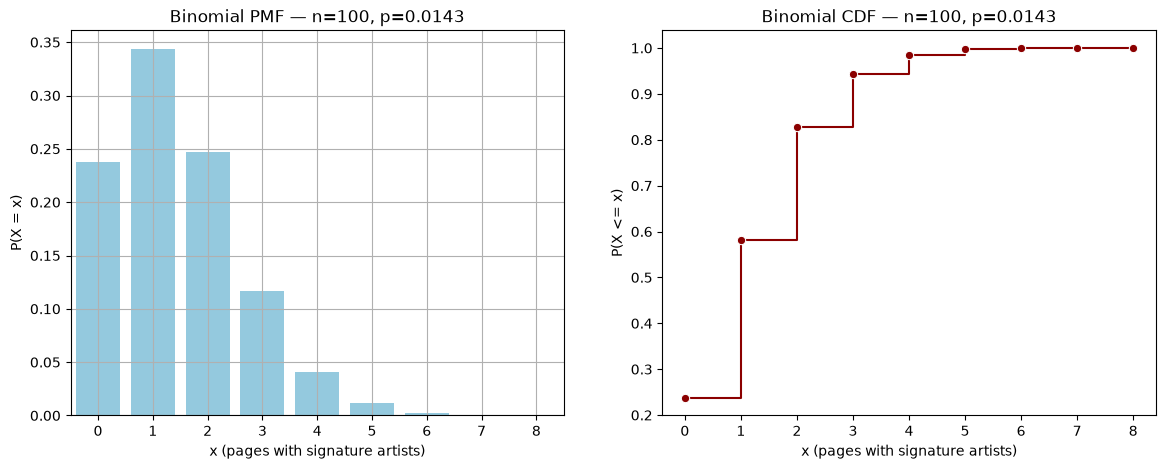

In [41]:
n, p = 100, 8/560
x = np.arange(0, 9)

# Build a DataFrame for seaborn
df = pd.DataFrame({
    "x": x,
    "pmf": stats.binom.pmf(x, n, p),
    "cdf": stats.binom.cdf(x, n, p),
})

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=df, x="x", y="pmf", color="skyblue", ax = ax[0])
ax[0].set_xlabel("x (pages with signature artists)")
ax[0].set_ylabel("P(X = x)")
ax[0].set_title(f"Binomial PMF — n={n}, p={p:.4f}")
ax[0].grid(visible=True)

sns.lineplot(data=df, x="x", y="cdf", marker="o", color="darkred", drawstyle="steps-post", ax=ax[1])
ax[1].set_xlabel("x (pages with signature artists)")
ax[1].set_ylabel("P(X <= x)")
ax[1].set_title(f"Binomial CDF — n={n}, p={p:.4f}")


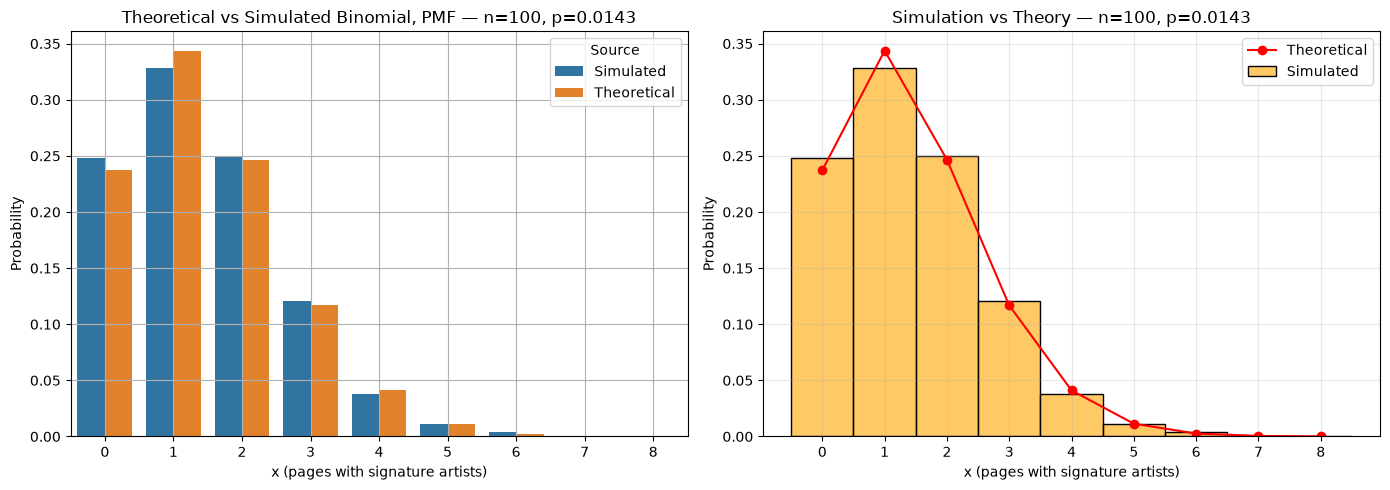

In [62]:
## Theoretical vs Simulated 
n, p = 100, 8/560
x = np.arange(0, 9)

rng = np.random.default_rng(42)
# 1000 observations (i.e experiments)
# this returns 1000 numbers between 0 and 8 resembling the count of success in 1000 experiments (each experiment has 100 trials)
samples = rng.binomial(n=n, p=p, size=1000) 

sim=pd.DataFrame({
    "x": x,
    "Simulated": [np.mean(samples == k) for k in x],
    "Theoretical": binom.pmf(k=x, n=n, p=p)
}).melt(id_vars="x", var_name="Source", value_name="Probability") # convert from wide format to long format

# print(sim)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=sim, x="x", y="Probability", hue="Source", ax=ax[0])
ax[0].set_xlabel("x (pages with signature artists)")
ax[0].set_ylabel("Probability")
ax[0].set_title(f"Theoretical vs Simulated Binomial, PMF — n={n}, p={p:.4f}")
ax[0].grid(visible=True)

sns.histplot(data=samples, bins=np.arange(-0.5, 9.5, 1),
             stat="probability", color="orange", alpha=0.6,
             label="Simulated", edgecolor="black", ax=ax[1])

# Draw the theoretical PMF line ON ax[1]
ax[1].plot(x, stats.binom.pmf(x, n, p), "ro-", label="Theoretical")

ax[1].set_xlabel("x (pages with signature artists)")
ax[1].set_ylabel("Probability")
ax[1].set_xticks(x)
ax[1].set_title(f"Simulation vs Theory — n={n}, p={p:.4f}")
ax[1].legend()                                    # show the labels
ax[1].grid(visible=True, alpha=0.3)

plt.tight_layout()
